In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tqdm.notebook as tqdm

sns.set()

In [74]:
data_path = '/home/dink/Documents/Research/data/wildfire_case_studies/Holiday_Farm_Year/'
results_path = '/home/dink/Documents/Research/Correlation-Changepoint-Detection/results/2022052317'
files = os.listdir(data_path)
results = os.listdir(results_path)
csv_files = list(filter(lambda f: f.endswith('.csv'), files))
csv_files = list(filter(lambda f: "Primary" in f, files))

In [75]:
print(len(csv_files))

24


In [76]:
drop_sensor_idx = np.array([7, 16, 19, 20, 21, 22, 23, 13, 11])
drop_sensor_idx -= 1
drop_sensor_idx

array([ 6, 15, 18, 19, 20, 21, 22, 12, 10])

In [77]:
keep_sensors = np.delete(np.array(csv_files), drop_sensor_idx)

In [78]:
sensor_names = [ks.split('(')[0][:-1].split('-')[-1].strip(' ') for ks in keep_sensors]
sensor_names

['Office Outside',
 'Crescent Park B',
 'Springfield City Hall B',
 'Springfield HS',
 'Walterville Elementary',
 'Office Inside',
 'Rosewold',
 'Crescent Park',
 'South Eugene HS',
 'Rosewold B',
 'Springfield City Hall',
 'Office Inside B',
 'Thurston HS B',
 'Agnes Stewart MS B',
 'Walterville Elementary B']

In [79]:
len(sensor_names)

15

In [80]:
len(csv_files)

24

In [81]:
results

['matrix_4.csv',
 'matrix_7.csv',
 'matrix_6.csv',
 'matrix_5.csv',
 'lrt_results.csv',
 'matrix_3.csv',
 'matrix_1.csv',
 'matrix_2.csv',
 'matrix_0.csv']

In [82]:
lrt_results = np.loadtxt(os.path.join(results_path, 'lrt_results.csv'), delimiter=',')
lrt_results.shape

(1416, 16)

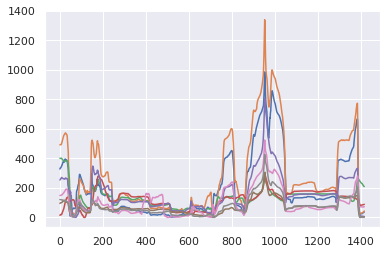

In [83]:
plt.plot(lrt_results[:, :8])

In [84]:
def symmetrize_from_vector(a, dim):
    """
    Turns a vector of lower triangular matrix entries into symmetric matrix
    """
    A = np.zeros((dim,dim))
    A[np.tril_indices(A.shape[0], k = 0)] = a
    A = A + A.T - np.diag(np.diag(A))

    return A

In [85]:
matrices = []
nonzero_idxs = []
for i in range(len(results)-1):
    mat = np.loadtxt(os.path.join(results_path, 'matrix_{}.csv'.format(i)), delimiter=',')
    matrices.append(symmetrize_from_vector(mat, dim=15))
    nonzero_idxs.append(np.where(matrices[i] != 0))
matrices = np.array(matrices)

In [86]:
nonzero_idxs

[(array([ 0,  0,  0,  2,  2,  2, 10, 10, 10]),
  array([ 0,  2, 10,  0,  2, 10,  0,  2, 10])),
 (array([1, 1, 1, 3, 3, 3, 7, 7, 7]), array([1, 3, 7, 1, 3, 7, 1, 3, 7])),
 (array([ 4,  4, 14, 14]), array([ 4, 14,  4, 14])),
 (array([ 5,  5, 11, 11]), array([ 5, 11,  5, 11])),
 (array([6, 6, 9, 9]), array([6, 9, 6, 9])),
 (array([8]), array([8])),
 (array([12]), array([12])),
 (array([13]), array([13]))]

In [87]:
matrices.shape

(8, 15, 15)

In [88]:
splits = [x.split('(') for x in csv_files]
splits = [sp[2].split(')') for sp in splits]
lats = []
longs = []
for sp in splits:
    curr = sp[0].split()
    lats.append(float(curr[0]))
    longs.append(float(curr[1]))

In [89]:
lats = np.delete(np.array(lats), drop_sensor_idx)
longs = np.delete(np.array(longs), drop_sensor_idx)

<AxesSubplot:>

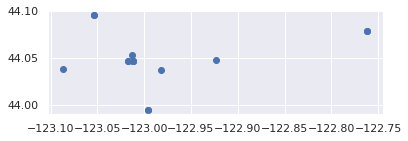

In [90]:
from shapely.geometry import Point
import geopandas as gpd
geometry = [Point(xy) for xy in zip(longs,lats)]
geo_df = gpd.GeoDataFrame(geometry = geometry)
geo_df.plot()

In [91]:
path = "/home/dink/Downloads/tl_2021_us_state.shp"
df = gpd.read_file(path)
df = df.to_crs("EPSG:4326")

In [92]:
non_continental = ['HI','VI','MP','GU','AK','AS','PR']
us49 = df
for n in non_continental:
    us49 = us49[us49.STUSPS != n]

In [93]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
def statePlot(st,data,cmap,zoom,dpi):
    state = us49.loc[us49['STUSPS'] == st]
    state.crs = "EPSG:4326"
    f,ax = plt.subplots(1,1, figsize=(8,8), 
    sharex=True,sharey=True, dpi=dpi)
    f.tight_layout(pad=0.8)
    ax.set_axis_off()
    plt.title('Map using Contextily - ' + data,fontsize='large')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.2)
    ux = state.to_crs(epsg=3857).plot(data, ax=ax, 
    edgecolor='blue',    cmap=cmap, alpha = 0.2, 
    legend=True, cax=cax)
    plt.ylabel('Million square miles', fontsize=12)
    # Use savefig to save your map
    plt.savefig(
    'US Contextily Map with zoom = ' + str(zoom) +' .png')
    plt.show()

In [94]:
def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(point['x']+.02, point['y'], str(point['val']))

In [95]:
cluster_vals = np.zeros(len(lats))
for k, nzi in enumerate(nonzero_idxs):
    items = set(nzi[0])
    items_two = set(nzi[1])
    print(items, items_two)
    for item in items:
        cluster_vals[item] = int(k)
cluster_vals

{0, 2, 10} {0, 2, 10}
{1, 3, 7} {1, 3, 7}
{4, 14} {4, 14}
{11, 5} {11, 5}
{9, 6} {9, 6}
{8} {8}
{12} {12}
{13} {13}


array([0., 1., 0., 1., 2., 3., 4., 1., 5., 4., 0., 3., 6., 7., 2.])

In [96]:
sensor_names = np.array(sensor_names)

In [97]:
print(len(sensor_names), len(cluster_vals))

15 15


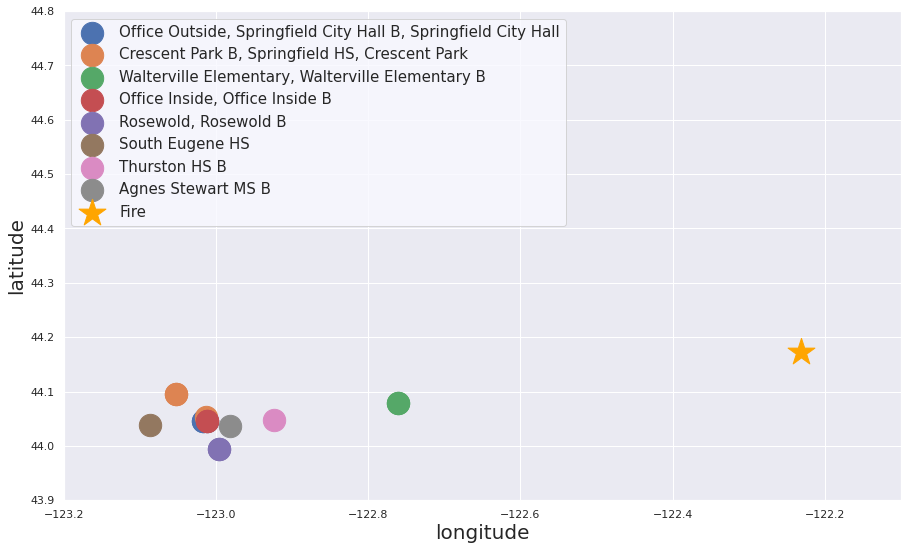

In [153]:
fig, ax = plt.subplots(figsize = (15, 9))
#base = us49.loc[us49['STUSPS'] == 'OR'].plot(ax=ax, edgecolor='blue', color='white')
labels = set(cluster_vals)
#print(cluster_vals == 0)
marker_list = ['o', 'v', '<', '>', '^', 's', 'p', 'D']
for label in labels:
    sensors_clust = sensor_names[cluster_vals == label]
    sensors_clust = ', '.join([''.join(name) for name in sensors_clust])
    plt.scatter(longs[cluster_vals == label], lats[cluster_vals == label], s=500, 
                label=sensors_clust, cmap='viridis', marker='o')
plt.scatter([-122.231],[44.172], color='orange', label='Fire', marker="*", s=800)
#plt.text(-122.231,44.172+0.01, "Fire Onset", fontsize=16)
plt.xlabel('longitude', fontsize=20)
plt.ylabel('latitude', fontsize=20)
plt.xlim(-123.2, -122.1)
plt.ylim(43.9, 44.8)
plt.legend(loc='upper left', fontsize=15, facecolor='ghostwhite')
# for package in zip(longs, lats, sensor_names):
#     name = package[2]
#     if 'Crescent Park B' in name:
#         plt.text(package[0]-0.01, package[1]+0.02, name, fontsize=14)
#     elif 'South' in name:
#         plt.text(package[0]-0.1, package[1]-0.01, name, fontsize=14)
#     elif 'Rosewold B' in name:
#         plt.text(package[0]+0.02, package[1]-0.015, name, fontsize=14)
#     elif 'Rosewold' in name:
#         plt.text(package[0]+0.02, package[1]-0.005, name, fontsize=14)
#     elif 'City Hall B' in name:
#         plt.text(package[0], package[1]-0.02, name, fontsize=14)
#     elif 'City Hall' in name:
#         plt.text(package[0], package[1]-0.028, name, fontsize=14)
#     elif 'Springfield HS' in name:
#         plt.text(package[0]-0.13, package[1]+0.007, name, fontsize=14)
#     elif 'Office Inside B' in name:
#         plt.text(package[0]-0.01, package[1]-0.005, name, fontsize=14)
#     elif 'Office Inside' in name:
#         plt.text(package[0]-0.01, package[1]+0.005, name, fontsize=14)
#     elif 'Walterville' in name:
#         plt.text(package[0]-0.01, package[1]-0.015, name, fontsize=14)
#     elif 'Thurston' in name:
#         plt.text(package[0]+0.02, package[1], name, fontsize=14)
#     elif 'Agnes' in name:
#         plt.text(package[0]+0.1, package[1], name, fontsize=14)
#     elif 'Office Outside' in name:
#         plt.text(package[0]+0.015, package[1]+0.015, name, fontsize=14)
#     else:
#         plt.text(package[0], package[1]+0.01, package[2], fontsize=14)


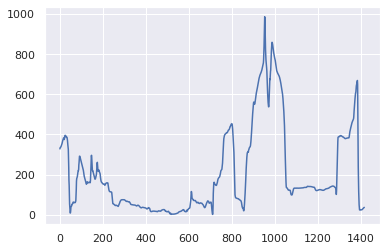

In [25]:
plt.plot(lrt_results[:, 0])

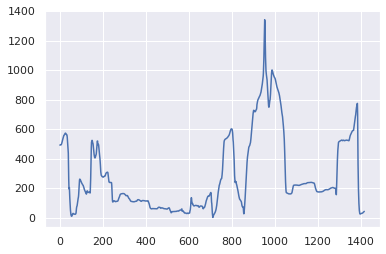

In [26]:
plt.plot(lrt_results[:, 1])

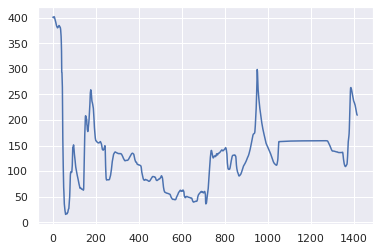

In [27]:
plt.plot(lrt_results[:, 2])

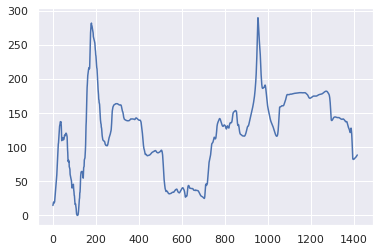

In [28]:
plt.plot(lrt_results[:, 3])

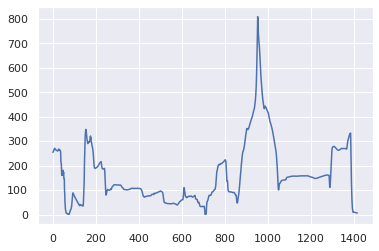

In [29]:
plt.plot(lrt_results[:, 4])

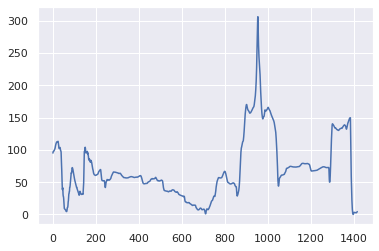

In [129]:
plt.plot(lrt_results[:, 5])

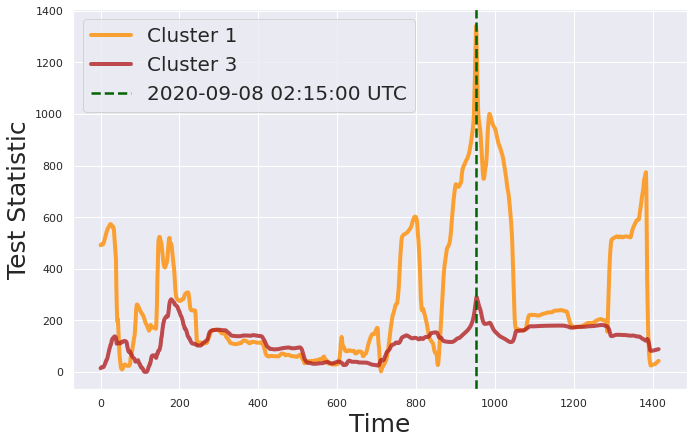

In [158]:
fig, ax = plt.subplots(figsize = (11, 7))
plt.plot(lrt_results[:, 1], label='Cluster 1', color='darkorange', alpha=0.8, linewidth=4)
plt.plot(lrt_results[:, 3], label='Cluster 3', color='firebrick', alpha=0.8, linewidth=4)
plt.xlabel('Time', fontsize=25)
plt.ylabel('Test Statistic', fontsize=25)
plt.axvline(x=952, ls='--', color='darkgreen', label='2020-09-08 02:15:00 UTC', linewidth=2.5)
plt.legend(loc='best', fontsize=20)

In [39]:
np.argmax(lrt_results[:, 1])

952

In [47]:
np.where(cluster_vals == 1)

(array([1, 3, 7]),)

In [135]:
np.where(cluster_vals == 3)

(array([ 5, 11]),)

In [137]:
sensor_names[1], sensor_names[3], sensor_names[7]

('PPPM - Crescent Park B', 'LRAPA-Springfield HS', 'PPPM - Crescent Park')

In [138]:
sensor_names[5], sensor_names[11]

('LRAPA-Office Inside', 'LRAPA-Office Inside B')

In [187]:
nonzero_idxs[1]

(array([1, 1, 1, 3, 3, 3, 7, 7, 7]), array([1, 3, 7, 1, 3, 7, 1, 3, 7]))

In [173]:
full_data_clean = pd.read_csv('../results/full_data_clean_idx.csv')
time_idx = pd.to_datetime(full_data_clean.created_at).iloc[22000:-10000]
time_idx = time_idx[::2]

In [174]:
time_idx.shape

(1616,)

In [175]:
lrt_results.shape

(1416, 16)

In [181]:
lrt_results_padded = np.pad(lrt_results, [(100, 100), (0,0)], mode='constant')

In [182]:
time_idx.shape, lrt_results_padded.shape

((1616,), (1616, 16))

In [185]:
temp_df = pd.DataFrame(index=time_idx)
temp_df.loc[:, 'Cluster 1'] = lrt_results_padded[:, 1]
temp_df.loc[:, 'Cluster 3'] = lrt_results_padded[:, 3]

,Cluster 1,Cluster 3
created_at,,
2020-08-17 04:00:00,0.0,0.0
2020-08-17 04:30:00,0.0,0.0
2020-08-17 05:00:00,0.0,0.0
2020-08-17 05:30:00,0.0,0.0
2020-08-17 06:00:00,0.0,0.0
...,...,...
2020-09-19 17:30:00,0.0,0.0
2020-09-19 18:00:00,0.0,0.0
2020-09-19 18:30:00,0.0,0.0


Text(0, 0.5, 'Test Statistic')

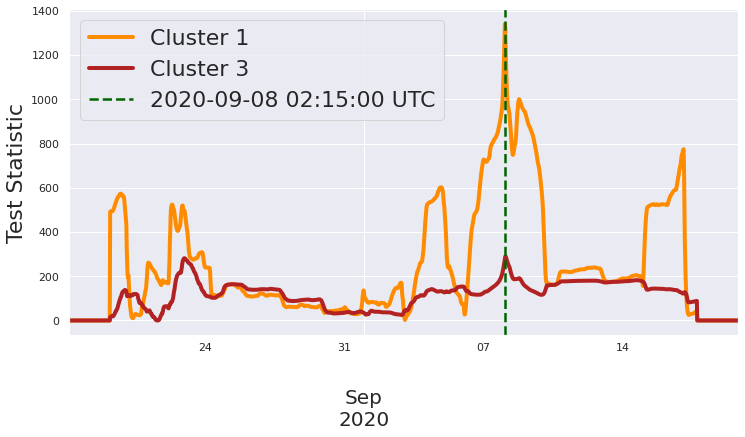

In [202]:
temp_df.plot(figsize=(12, 6), color=['darkorange', 'firebrick'], linewidth=4)
plt.axvline(x='2020-09-08 02:15:00 UTC', ls='--', color='darkgreen', label='2020-09-08 02:15:00 UTC', 
            linewidth=2.5)
plt.legend(loc='upper left', fontsize=22)
plt.xlabel('')
plt.xticks(fontsize=20)
plt.ylabel('Test Statistic', fontsize=22)